## NB03-Data Analysis

Input: the tidy tables from NB02 (`data/processed/movies.csv`, `data/processed/movie_genres.csv`).
Output: exploratory tables, figures saved to `docs/assets/` (used by the public website), and three central findings.

This notebook is exploratory: it summarises, groups, and plots the prepared data. It does not build predictive or machine-learning models, and it does not repeat the collection or preparation work.

The three findings I develop here, each answering part of the question:

1. Runtime - have popular movies grown longer over the decades?
2. Genres - which genres dominate, and how does that mix shift over time?
3. Rating - do average audience ratings drift across decades?

## 1. Load the prepared data


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("..") / "data" / "processed"
ASSETS_DIR = Path("..") / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

movies = pd.read_csv(PROCESSED_DIR / "movies.csv")
movie_genres = pd.read_csv(PROCESSED_DIR / "movie_genres.csv")

print(f"movies:        {len(movies)} rows")
print(f"movie_genres:  {len(movie_genres)} rows")
print(f"Year range:    {movies['year'].min()}-{movies['year'].max()}")
movies.head()

movies:        1220 rows
movie_genres:  3202 rows
Year range:    1960-2020


,movie_id,title,year,runtime,vote_average,vote_count,budget,revenue,original_language,decade
0,100,"Lock, Stock and Two Smoking Barrels",1998,105,8.097,7279,1350000.0,28356188.0,en,1990
1,10014,A Nightmare on Elm Street Part 2: Freddy's Rev...,1985,87,5.800,2141,3000000.0,30000121.0,en,1980
2,10020,Beauty and the Beast,1991,84,7.726,10772,25000000.0,424967620.0,en,1990
3,100402,Captain America: The Winter Soldier,2014,136,7.655,20180,170000000.0,714766572.0,en,2010
4,10072,A Nightmare on Elm Street 3: Dream Warriors,1987,96,6.717,2065,4450000.0,44793222.0,en,1980


## 2. How many movies per decade?

Before drawing conclusions, we check how much data supports each decade. If a decade has very few movies, we read its averages with caution.

decade
1960    200
1970    200
1980    200
1990    200
2000    200
2010    200
2020     20
Name: n_movies, dtype: int64


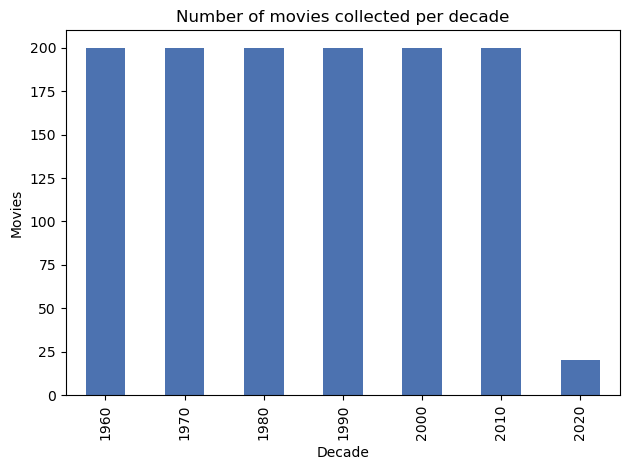

In [3]:
per_decade = movies.groupby("decade").size().rename("n_movies")
print(per_decade)

ax = per_decade.plot(kind="bar", color="#4C72B0")
ax.set_title("Number of movies collected per decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Movies")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "movies_per_decade.png", dpi=120)
plt.show()

In [5]:
first_decade = runtime_by_decade.index.min()
last_decade = runtime_by_decade.index.max()
change = runtime_by_decade.loc[last_decade] - runtime_by_decade.loc[first_decade]
print(
    f"FINDING 1: Mean runtime went from {runtime_by_decade.loc[first_decade]:.1f} min "
    f"in the {first_decade}s to {runtime_by_decade.loc[last_decade]:.1f} min in the "
    f"{last_decade}s (a change of {change:+.1f} min)."
)


FINDING 1: Mean runtime went from 115.8 min in the 1960s to 118.0 min in the 2020s (a change of +2.2 min).


As expected, we can see that the 2020s have the least data (since we only included one year). Consequently, the averages will not be as reliable as those for other time periods.

## 3. Finding 1 - Runtime across the decades

We compute the mean runtime by decade. Using the mean of a numeric column grouped by decade is the simplest summary that answers "are movies getting longer?".

Mean runtime (minutes) by decade:
decade
1960    115.8
1970    113.7
1980    109.3
1990    118.4
2000    120.5
2010    124.9
2020    118.0
Name: runtime, dtype: float64


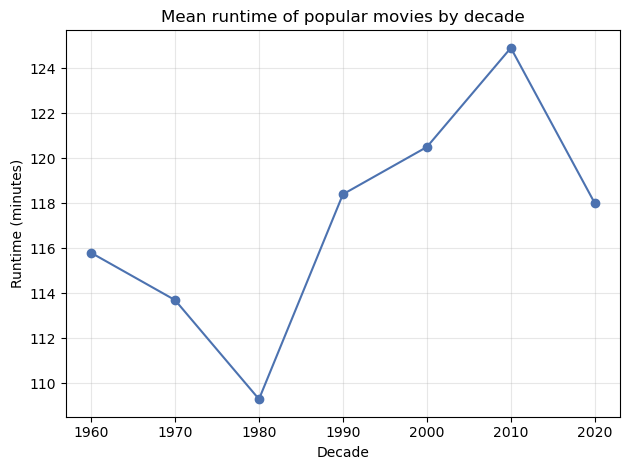

In [4]:
runtime_by_decade = movies.groupby("decade")["runtime"].mean().round(1)
print("Mean runtime (minutes) by decade:")
print(runtime_by_decade)

ax = runtime_by_decade.plot(marker="o", color="#4C72B0")
ax.set_title("Mean runtime of popular movies by decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Runtime (minutes)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "runtime_by_decade.png", dpi=120)
plt.show()


## 4. Finding 2 - Genre mix across the decades

Count genre mentions per decade from the long table, convert to shares (%), track the overall top genres.


In [6]:
top_genres = movie_genres["genre"].value_counts().head(6).index.tolist()
print("Top genres overall:", top_genres)
counts = (movie_genres[movie_genres["genre"].isin(top_genres)]
          .groupby(["decade", "genre"]).size().rename("n").reset_index())
totals = movie_genres.groupby("decade").size().rename("total")
counts = counts.join(totals, on="decade")
counts["share"] = (counts["n"] / counts["total"] * 100).round(1)
genre_share = counts.pivot(index="decade", columns="genre", values="share").fillna(0)
print("\nGenre share (% of genre mentions) by decade:")
print(genre_share)


Top genres overall: ['Drama', 'Action', 'Comedy', 'Adventure', 'Thriller', 'Science Fiction']

Genre share (% of genre mentions) by decade:
genre   Action  Adventure  Comedy  Drama  Science Fiction  Thriller
decade                                                             
1960       4.1        7.7    13.3   22.4              2.7       8.3
1970       8.4        7.0    11.9   18.7              6.8       9.9
1980      11.6       10.4    13.0   11.2              8.3       9.4
1990       9.7        7.5    12.1   15.2              5.5       9.7
2000      14.4       12.2     9.2   11.1              8.1      10.2
2010      16.3       17.2     6.7   10.8             12.6       7.7
2020      20.0       10.0     8.3    5.0              8.3       8.3


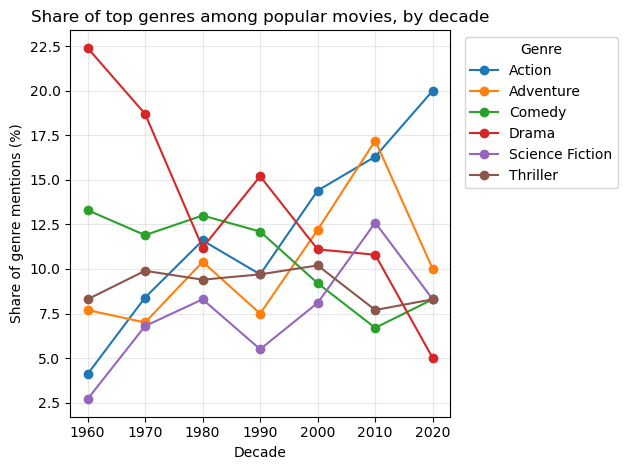

In [7]:
ax = genre_share.plot(marker="o")
ax.set_title("Share of top genres among popular movies, by decade")
ax.set_xlabel("Decade"); ax.set_ylabel("Share of genre mentions (%)")
ax.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(ASSETS_DIR / "genre_share_by_decade.png", dpi=120); plt.show()


In [8]:
first, last = genre_share.index.min(), genre_share.index.max()
delta = (genre_share.loc[last] - genre_share.loc[first]).sort_values()
print(f"FINDING 2 (change in share, {first}s -> {last}s):")
print(f"  Biggest riser: {delta.index[-1]} ({delta.iloc[-1]:+.1f} pts)")
print(f"  Biggest faller: {delta.index[0]} ({delta.iloc[0]:+.1f} pts)")


FINDING 2 (change in share, 1960s -> 2020s):
  Biggest riser: Action (+15.9 pts)
  Biggest faller: Drama (-17.4 pts)
